## Machine Learning : Theory and Applications (2025/26)
Simona Cocco & Vito Dichio

[✉ simona.cocco@phys.ens.fr](mailto:simona.cocco@phys.ens.fr) \\
[✉ vito.dichio@phys.ens.fr](mailto:vito.dichio@phys.ens.fr)


**Date:** Wed December 10 2025 8:30AM - Thu December 11 2025 10:30AM

#### Bibliography:

[1] Cocco et al., *From Statistical Physics to Data-Driven Modelling: with Applications to Quantitative Biology*, Oxford University Press (2022)



# ML for Neuroscience — Practical Exam (START)

### Topic : Perceptron Capacity and Multi-Class Classification

In **Tutorial 4**, you learned the perceptron algorithm for binary classification using the **signed pattern formulation**. You applied this to distinguish MNIST digits **0 vs 1**. In this exam, you will further explore the Perceptron's algorithm and extend these ideas to more challenging scenarios.

This exam consists of two parts:

#### **Part A: Critical Capacity of the Perceptron**
Investigate the theoretical storage capacity of the perceptron by training on random binary patterns. You will empirically verify the critical capacity of the perceptron: $\alpha_c \sim 2$.

#### **Part B: Multi-Class Classification with One-vs-One Strategy**
Extend the binary perceptron to classify all 10 MNIST digits using the one-vs-one (OVO) approach. You will analyze performance using confusion matrices and understand the importance of the bias term.


# Part A: Critical Capacity of the Perceptron

### Theoretical Background

In Tutorial 4, you applied the perceptron to MNIST digits (0 vs 1), which have structure and patterns. But what happens when we try to memorize **completely random associations** between inputs and outputs?

We consider $M$ **binary random patterns:** both inputs $x^{(m)} \in \{0, 1\}^L$ and labels $y^{(m)} \in \{0, 1\}$ are drawn uniformly at random, with no correlation. Here, $L$ is the dimension of the input space (number of features) and $M$ is the number of patterns to classify.

Consider a perceptron learning problem with **loading parameter** $\alpha = M/L$. For random binary patterns in the double infinite size limit $M, L \to \infty$ with fixed ratio $\alpha = M/L$, the **critical capacity** is $\alpha_c \approx 2$. This means:
- **$\alpha < \alpha_c$**: Random patterns are typically linearly separable $\Rightarrow$ perceptron converges
- **$\alpha > \alpha_c$**: Patterns typically NOT linearly separable $\Rightarrow$ perceptron fails to converge

For finite $L$ the transition is not infinitely sharp but occurs over a range around $\alpha_c \approx 2$. The transition becomes sharper as $L$ increases (see [1] Sec. 7.2.2, Figure 7.5 for illustration of finite-size effects).

**Your task:** Empirically verify this theorem by training perceptrons on random patterns for various $\alpha$ values and observing the convergence rate transition at $\alpha_c \approx 2$.

### 🎯 Question A.1: Generate Random Patterns

Implement a function called `generate_random_patterns` to generate random binary patterns and labels. The function should take as input the number of patterns `M`, the dimension `L`, and a random seed for reproducibility.

**Requirements:**
- Use `np.random.default_rng(seed)` for the random number generator
- Both patterns and labels should be uniformly random in $\{0, 1\}$
- Ensure not all labels are identical (redraw if needed, max 10 attempts)
- Each call with the same seed should produce identical results

Test your function for reproducibility by calling it twice with the same seed and checking that the outputs match. Use as `M`, `L` and `seed` the day, month and year of your **oral exam date** (e.g., for December 18, 2025 use `M=18`, `L=12`, `seed=2025`).

***Important note:*** I created a GitHub repository with all the machine learning scripts, including this exam's. I tried to push several commits during the making of the exam, so if you go to the previous code you can see my test cells, etc... The link to the repo is: https://github.com/brucsk/machine-learning-cogmaster-m2 

In [1]:
# Question A.1
import numpy as np 
from numpy.typing import NDArray

def generate_random_patterns(L: int, M: int, seed: int, verbose = True) -> (NDArray[int], NDArray[int]):
    """Generate M random binary patterns of dimension L, with associated labels.

    Each pattern is a vector of length L with entries -1 or +1.

    Parameters
    ----------
        L (int): Dimension of each pattern.
        M (int): Number of patterns to generate.
        seed (int, optional): Random seed for reproducibility. 

    Returns
    -------
        patterns (np.ndarray): Array of shape (M, L) containing the generated binary patterns.
        labels (np.ndarray): Array of shape (M,) containing the labels for each pattern.
    """
    rng = np.random.default_rng(seed)
    # Return random integers from low (inclusive) to high (exclusive) from the “discrete uniform” distribution
    patterns = np.array([rng.integers(low = 0, high = 2, size = L, dtype=int) for _ in range(M)])
    # Return M random labels
    labels = rng.integers(low=0, high=2, size=M, dtype=int)
    
    if verbose:
        print("Shape of patterns:", patterns.shape)
        print("First 5 patterns:\n", patterns[:5])
        print("Shape of labels:", labels.shape)
        print("First 5 labels:", labels[:5])
    return patterns, labels

In [3]:
# Sanity check
# Check that two calls to the function with the same seed produce the same patterns 
# Oral exam date : 17/12/2025
M_test = 17 
L_test = 12
SEED = 2025 # Set a seed for reproducibility

print("Call 1")
print("-"*12)
patterns_1, labels_1 = generate_random_patterns(L=L_test, M=M_test, seed = SEED, verbose=True)
print("\nCall 2")
print("-"*12)
patterns_2, labels_1 = generate_random_patterns(L=L_test, M=M_test, seed = SEED, verbose=True)

Call 1
------------
Shape of patterns: (17, 12)
First 5 patterns:
 [[0 1 1 0 1 1 1 1 1 1 0 0]
 [0 0 0 1 1 1 1 0 0 0 0 0]
 [1 0 0 0 0 1 1 0 0 0 1 0]
 [1 0 0 0 0 0 0 1 0 1 1 1]
 [0 0 0 0 0 0 0 0 1 1 1 1]]
Shape of labels: (17,)
First 5 labels: [1 1 1 1 0]

Call 2
------------
Shape of patterns: (17, 12)
First 5 patterns:
 [[0 1 1 0 1 1 1 1 1 1 0 0]
 [0 0 0 1 1 1 1 0 0 0 0 0]
 [1 0 0 0 0 1 1 0 0 0 1 0]
 [1 0 0 0 0 0 0 1 0 1 1 1]
 [0 0 0 0 0 0 0 0 1 1 1 1]]
Shape of labels: (17,)
First 5 labels: [1 1 1 1 0]


### 🎯 Question A.2: Test Capacity for Single Configuration

Implement a function `test_capacity` that tests perceptron capacity for a range of $\alpha$ values with fixed $L$. The function should take as input:
- `alpha_values`: array of $\alpha$ values to test
- `L`: dimension of input patterns
- `n_trials`: number of random trials per $\alpha$
- `max_updates`: maximum perceptron updates per trial

**Algorithm for each $\alpha$:**
1. Compute the number of patterns given `alpha` and `L`
2. For each trial:
   - Generate random patterns **using as seed the trial index** for reproducibility
   - Train perceptron using the perceptron learning algorithm with a maximum of `max_updates` updates
   - Predict and compute **training error**
   - Count as "converged" if training error is $\approx 0$  up to a difference of `1e-6` (use `np.isclose`)
3. Compute convergence rate: `converged_count / n_trials`
4. Compute mean training error across all trials

The function should finally return a DataFrame with columns: `alpha`, `convergence-rate`, `training error` as output.

**Test your function:**
```python
# Quick test with small parameters
alpha_test = np.linspace(0.25, 4.0, 16)
df_test = test_capacity(alpha_test, L=10, n_trials=10, max_updates=1000)

print(df_test)
# Should show high convergence rate for α < 2, lower for α > 2
```

💡 **Hint:** You may want to reuse the functions  `perceptron_signed`, `linear_classifier_predict` and `compute_error_rate` for an efficient implementation of the perceptron training and evaluation.


In [4]:
# Question A.2
import numpy as np 
from numpy.typing import NDArray
import pandas as pd

# Helper functions from tutorial 4
def perceptron_signed(X_train, y_train, max_updates=2000, c_threshold=np.inf, track_history=False):
    """
    Perceptron algorithm using signed pattern formulation.

    Parameters
    ----------
    X_train : ndarray, shape (n_samples, n_features)
        Training data (flattened images). Each row is one example x^(m).
    y_train : ndarray, shape (n_samples,)
        Labels in {-1, +1}.
    max_updates : int, optional
        Maximum number of weight updates (default 2000).
    c_threshold : float, optional
        Stopping threshold on minimum stability (default np.inf, meaning only max_updates stops).
    track_history : bool, optional
        If True, track stability and error evolution; if False, only return final weights.

    Returns
    -------
    result : dict
        Always contains:
        - 'J' : ndarray, shape (n_features,)
            Final weight vector (normalized to unit norm).
        - 'n_updates' : int
            Number of updates performed.

        If track_history=True, also contains:
        - 'c_min_normalized_list' : list of float
            Normalized minimum stabilities (c_min / ||J||) after each update.
        - 'train_error_list' : list of float
            Training error rate after each update.
    """
    # -------------------------------------------------------------------------
    # 1. - 2. Input validation and preparation
    # -------------------------------------------------------------------------
    X = np.asarray(X_train)
    y = np.asarray(y_train)
    # Prepare labels in {-1, +1}
    y = np.where(y == 1, 1, -1)

    n_samples, n_features = X.shape

    # Create signed patterns: eta^(m) = y^(m) * x^(m)
    eta = y[:, None] * X  # shape (n_samples, n_features)

    # -------------------------------------------------------------------------
    # 3. Initialize algorithm state
    # -------------------------------------------------------------------------
    J = np.zeros(n_features)  # Weight vector
    c_min = 0.0  # Current minimum stability
    n_updates = 0  # Update counter

    # Initialize history tracking if needed
    if track_history:
        c_min_t = []
        train_error_t = []

    # -------------------------------------------------------------------------
    # 4. Main perceptron loop
    # -------------------------------------------------------------------------
    while (c_min < c_threshold) and (n_updates < max_updates):

        # (a) Compute stabilities for all samples
        stabilities = eta @ J  # shape (n_samples,)

        # (b) Find pattern with minimum stability (most violated)
        m_worst = np.argmin(stabilities)
        c_min = float(stabilities[m_worst])

        # (c) Track history BEFORE update (to see convergence evolution)
        if track_history and n_updates > 0:  # Skip first iteration (J=0)
            J_norm = np.linalg.norm(J)
            if J_norm > 0:
                c_min_t.append(c_min / J_norm)
            else:
                c_min_t.append(0.0)

        # (d) Perceptron update: add worst pattern to weights
        J = J + eta[m_worst, :]
        n_updates += 1

        # (e) Track training error AFTER update (to see current performance)
        if track_history:
            predictions = linear_classifier_predict(X, J)
            train_error = compute_error_rate(y_train, predictions)
            train_error_t.append(train_error)

    # -------------------------------------------------------------------------
    # 5. Finalize and return results
    # -------------------------------------------------------------------------

    # Normalize final weight vector
    J_norm = np.linalg.norm(J)
    if J_norm > 0:
        J = J / J_norm

    # Build result dictionary
    result = {
        'n_updates': n_updates,
        'J': J
    }

    # Add history tracking results if enabled
    if track_history:
        result['c_min_t'] = c_min_t
        result['train_error_t'] = train_error_t

    return result

def linear_classifier_predict(X, d, theta=0.0):
    """
    Predict labels using linear classifier with direction d and threshold theta

    Decision rule: predict 1 if d·x > theta, else predict 0

    Parameters
    ----------
    X : array (n_samples, n_features)
        Data to classify (flattened images)
    d : array (n_features,)
        Direction vector (e.g., difference of averages)
    theta : float
        Decision threshold

    Returns
    -------
    predictions : array (n_samples,)
        Predicted labels (0 or 1)
    """
    scores = X @ d  # Compute d·x for all samples
    predictions = (scores > theta).astype(int)
    return predictions


def compute_error_rate(y_true, y_pred, verbose=False):
    """
    Compute classification error rate

    Parameters
    ----------
    y_true : array (n_samples,)
        True labels
    y_pred : array (n_samples,)
        Predicted labels
    verbose : bool
        If True, print number of correct predictions and mistakes

    Returns
    -------
    error_rate : float
        Error rate (proportion of mistakes, between 0 and 1)
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    if y_true.size == 0:
        if verbose:
            print("No samples provided.")
        return 0.0

    mistakes = np.sum(y_true != y_pred)
    correct = y_true.size - mistakes
    error_rate = mistakes / y_true.size

    if verbose:
        print(f"Correct: {correct}, Mistakes: {mistakes} | Error rate: {error_rate*100 :.2f}%")

    return error_rate

# New function to test capacity of perceptron
def test_capacity(alpha_values: NDArray[np.float64], L: int, n_trials: int, max_updates: int) -> pd.DataFrame:
    """ Tests capacity of a perceptron for a range of alpha values with fixed L
    
    Parameters
    ----------
        alpha_values (np.ndarray): List of alpha values to test.
        L (int): Dimension of each pattern.
        n_trials (int): Number of trials for each alpha value.
        max_updates (int): Maximum number of updates for the perceptron learning algorithm.

    Returns
    -------
        results_df (pd.DataFrame): DataFrame with columns: "alpha", "convergence-rate", "training error"
                                   each row corresponds to an alpha value and corresponding metrics.
    """
    # Initialize arrays to store mean convergence rates and training errors for each alpha
    convergence_rates = np.zeros(len(alpha_values))
    training_errors = np.zeros(len(alpha_values))
    
    for i, alpha in enumerate(alpha_values):
        # Compute the number of patterns given alpha and L (alpha = M / L)
        nb_patterns = int(alpha * L) 
        converged_count = 0
        for trial in range(n_trials):
            # Generate random patterns using the trial as seed for reprocucibility
            patterns_trial, labels_trial = generate_random_patterns(L = L, M = nb_patterns, seed = trial, verbose = False)
            # Train perceptron using the perceptron learning algorithm with a maximum of "max_updates" updates
            results = perceptron_signed(X_train = patterns_trial, y_train = labels_trial,
                            max_updates = max_updates, c_threshold = np.inf, track_history = True
                            )
                            
            # Predict and compute **training error**
            J = results["J"]
            pred_trial = linear_classifier_predict(X = patterns_trial, d = J, theta=0.0)
            error_rate = compute_error_rate(labels_trial, pred_trial, verbose=False)
            training_errors[i] += error_rate
            # Count as "converged" if training error is $\approx 0$  up to a difference of `1e-6` (use `np.isclose`)
            if np.isclose(error_rate, 0.0, atol=1e-6):
                converged_count += 1

        # Compute convergence rate: `converged_count / n_trials`
        convergence_rates[i] = converged_count / n_trials
        # Compute mean training error across all trials
        training_errors[i] = training_errors[i] / n_trials

    results = pd.DataFrame({
                "alpha": alpha_values,
                "convergence_rate": convergence_rates,
                "training_error": training_errors
            })
    return results

# Quick test with small parameters
alpha_test = np.linspace(0.25, 4.0, 16)
df_test = test_capacity(alpha_test, L=10, n_trials=10, max_updates=1000)

print(df_test)
# Should show high convergence rate for α < 2, lower for α > 2

    alpha  convergence_rate  training_error
0    0.25               1.0        0.000000
1    0.50               1.0        0.000000
2    0.75               1.0        0.000000
3    1.00               1.0        0.000000
4    1.25               0.9        0.025000
5    1.50               0.6        0.093333
6    1.75               0.5        0.158824
7    2.00               0.1        0.430000
8    2.25               0.3        0.345455
9    2.50               0.2        0.360000
10   2.75               0.0        0.418519
11   3.00               0.0        0.490000
12   3.25               0.0        0.475000
13   3.50               0.0        0.505714
14   3.75               0.0        0.505405
15   4.00               0.0        0.477500


### 🎯 Question A.3: Run Capacity Experiments

Run systematic experiments to verify the critical capacity $\alpha_c \approx 2$ and investigate how dimension $L$ and training time affect the transition.

#### (i) Run experiments

**Experimental parameters:**
- `alpha_values = np.linspace(0.5, 3.0, 11)` - Range of loading parameters
- `n_trials = 100` - Number of independent trials per configuration
- Test all 4 combinations of:
  - `L = 10, 50` - Pattern dimensions
  - `max_updates = 1000, 5000` - Training budget

**Task:** For each of the 4 configurations, run `test_capacity` and store results. You should obtain 4 DataFrames, one per combination of (`L`, `max_updates`).


In [5]:
# Question A.3
# Fixed experimental parameters
alpha_values = np.linspace(0.5, 3.0, 11) # Range of loading parameters
n_trials = 100 # Number of independent trials per configuration

# Test parameters
L_values = [10, 50] # Pattern dimensions 
max_updates_values = [1000, 5000] # Training budgets 

combinations_test = [ (L_values[i], max_updates_values[j]) 
                      for i in range(len(L_values))
                      for j in range(len(max_updates_values)) 
                    ]

# Initialize list of dataframes to store results
results_df_list = []

# Test all 4 combinations of L_values and max_updates_values
results_df_list = [
    test_capacity(alpha_values=alpha_values,
                  L=L_temp,
                  n_trials=n_trials,
                  max_updates=max_updates_temp)
    for L_temp in L_values
    for max_updates_temp in max_updates_values
]

# Small test
for i in range(len(results_df_list)):
  L, max_updates = combinations_test[i]
  print(f"Results for L={L}, max_updates={max_updates}:")
  print(results_df_list[i])
  print("\n")

Results for L=10, max_updates=1000:
    alpha  convergence_rate  training_error
0    0.50              1.00        0.000000
1    0.75              1.00        0.000000
2    1.00              0.93        0.024000
3    1.25              0.92        0.018333
4    1.50              0.73        0.084667
5    1.75              0.42        0.212353
6    2.00              0.26        0.302500
7    2.25              0.25        0.306818
8    2.50              0.11        0.388400
9    2.75              0.04        0.431852
10   3.00              0.00        0.456667


Results for L=10, max_updates=5000:
    alpha  convergence_rate  training_error
0    0.50              1.00        0.000000
1    0.75              1.00        0.000000
2    1.00              0.95        0.016000
3    1.25              0.92        0.019167
4    1.50              0.79        0.069333
5    1.75              0.50        0.197647
6    2.00              0.31        0.280000
7    2.25              0.29        0.288182
8 

#### (ii) Plot the results

Create **two plots** showing all 4 experimental configurations: in the first plot, show convergence rate vs $\alpha$; in the second plot, show mean training error vs $\alpha$.

Mark the theoretical critical capacity $\alpha_c \approx 2$ with a vertical dashed black line in both plots. Use distinct colors or markers for each configuration.


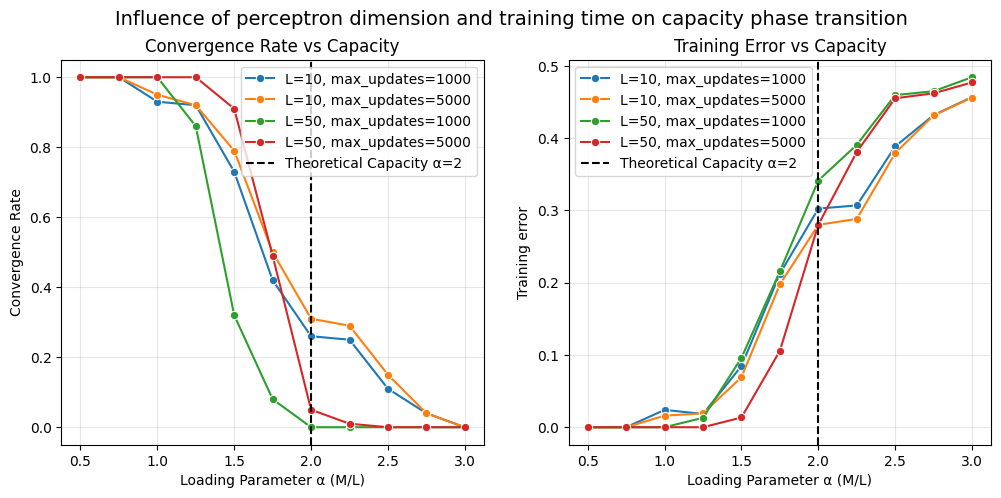

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

def plot_perceptron_results(results_df_list: list[pd.DataFrame], combinations_test: list[tuple]) -> None:
    """ Create two plots showing different exxperimental configurations of perceptron capacity test:
    the first plot shows convergence rate vs alpha, the second plot shows training error vs alpha.
    
    Parameters
    ----------
        results_df (pd.DataFrame): DataFrame with columns: "alpha", "convergence-rate", "training error"
        combinations_test (list of tuple): List of tuples (L, max_updates) corresponding the testing params of each df
    """
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    for i, df in enumerate(results_df_list):
        L, max_updates = combinations_test[i]

        label = f"L={L}, max_updates={max_updates}"
        
        # Plot convergence rate
        ax = axs[0]
        sns.lineplot(ax=ax, data=df, x='alpha', y='convergence_rate', marker='o', label=label)
        
        # Plot training error
        ax = axs[1]
        sns.lineplot(ax=ax, data=df, x='alpha', y='training_error', marker='o', label=label)

    ax = axs[0]
    ax.axvline(x=2.0, color='k', linestyle='--', label='Theoretical Capacity α=2')
    ax.set_ylabel('Convergence Rate')
    ax.set_xlabel('Loading Parameter α (M/L)')
    ax.set_title('Convergence Rate vs Capacity')
    ax.grid(alpha=0.3)
    ax.legend()

    ax = axs[1]
    ax.axvline(x=2.0, color='k', linestyle='--', label='Theoretical Capacity α=2')
    ax.set_ylabel('Training error')
    ax.set_xlabel('Loading Parameter α (M/L)')
    ax.set_title('Training Error vs Capacity')
    ax.grid(alpha=0.3)

    fig.suptitle('Influence of perceptron dimension and training time on capacity phase transition', fontsize=14)
    ax.legend()
    plt.show()

plot_perceptron_results(results_df_list, combinations_test)

#### (iii) Interpret the results

Comment on your findings from the experiments and plots. Address the following points:

1. **Critical capacity identification:** At what $\alpha$ value does the convergence rate drop most sharply for each configuration? How close are these values to the theoretical prediction $\alpha_c = 2$?

2. **Finite-size effects:** Compare the transition width for $L=10$ vs $L=50$. Does the transition become sharper for larger $L$, as predicted by theory? Cf Figure 7.5 in [1].

3. **Role of training budget:** Does increasing `max_updates` from 1000 to 5000 change the results? Specifically, does it affect the convergence rate near the critical region? If so, in which direction and why?

4. **Error behavior:** Examine the training error plots:
   - How does mean training error evolve as $\alpha$ increases?
   - For $\alpha > 2$, why is the error non-zero even though the perceptron runs for many updates?
   - Compare error curves for different `max_updates`: does training longer always help?

In [7]:
# (iii) 
# Numerical approaches
import numpy as np

# 1. Critical capacity identification
print("1. Critical capacity identification")
print("-"*12)
# First approach: rough estimate 
thres = 0.5 # threshold for considering convergence rate significantly dropped
alpha_c_theor = 2.0 # Theoretical critical capacity for perceptron

def rough_estimate_alpha_c(df, thres: float) -> float:
    alpha = df["alpha"].to_numpy()
    conv  = df["convergence_rate"].to_numpy()

    # Make sure sorted by alpha just in case
    order = np.argsort(alpha)
    alpha = alpha[order]
    conv  = conv[order]

    # Find first index where we cross from >= target to < target
    above = conv >= thres
    below = conv < thres

    crossing_idx = np.where(above[:-1] & below[1:])[0]
    if crossing_idx.size == 0:
        # No crossing found (always above or always below target)
        return np.nan

    i = crossing_idx[0]
    return float(alpha[i])
    
print("First approach:")
for i, results_df_temp in enumerate(results_df_list):
  L, max_updates = combinations_test[i]
  alpha_c = rough_estimate_alpha_c(results_df_temp, thres = thres)
  print(rf"L={L}, max_updates={max_updates} : α_c = {alpha_c:.2f}")

  #print("\n")

# Second approach: interception between tangent and c(alpha) = 0.5
def estimate_alpha_c(df, thres: float) -> float:
    alpha = df["alpha"].to_numpy()
    conv  = df["convergence_rate"].to_numpy()

    # Make sure sorted by alpha just in case
    order = np.argsort(alpha)
    alpha = alpha[order]
    conv  = conv[order]

    # Find first index where we cross from >= target to < target
    above = conv >= thres
    below = conv < thres

    crossing_idx = np.where(above[:-1] & below[1:])[0]
    if crossing_idx.size == 0:
        # No crossing found (always above or always below target)
        return np.nan

    i = crossing_idx[0]
    a0, a1 = alpha[i], alpha[i + 1]
    y0, y1 = conv[i], conv[i + 1]

    # Linear interpolation of y(α) between (a0, y0) and (a1, y1)
    # y(α_c) = target  ⇒  α_c = a0 + (target - y0) * (a1 - a0) / (y1 - y0)
    alpha_c = a0 + (thres - y0) * (a1 - a0) / (y1 - y0)
    return float(alpha_c)

print("\n")
print("Second approach:")
for i, results_df_temp in enumerate(results_df_list):
  L, max_updates = combinations_test[i]
  alpha_c = estimate_alpha_c(results_df_temp, thres = thres)
  print(rf"L={L}, max_updates={max_updates} : α_c = {alpha_c:.3f}")

print("\n")
print("Relative difference between two approaches (alpha_c1 - alpha_c2) / alpha_c2):")
for i, results_df_temp in enumerate(results_df_list):
  L, max_updates = combinations_test[i]
  relative_diff_alphas_c = (estimate_alpha_c(results_df_temp, thres = thres) - rough_estimate_alpha_c(results_df_temp, thres = thres))/ rough_estimate_alpha_c(results_df_temp, thres = thres)
  print(rf"L={L}, max_updates={max_updates} : relative difference = {relative_diff_alphas_c:.3f}")

print("\n")
print("Relative difference between α theoretical and empirical:")
for i, results_df_temp in enumerate(results_df_list):
  L, max_updates = combinations_test[i]
  rel_diff_alphaT_alphaE =(alpha_c_theor - estimate_alpha_c(results_df_temp, thres = thres))/ alpha_c_theor
  print(rf"L={L}, max_updates={max_updates} : relative difference = {rel_diff_alphaT_alphaE:.3f}")



1. Critical capacity identification
------------
First approach:
L=10, max_updates=1000 : α_c = 1.50
L=10, max_updates=5000 : α_c = 1.75
L=50, max_updates=1000 : α_c = 1.25
L=50, max_updates=5000 : α_c = 1.50


Second approach:
L=10, max_updates=1000 : α_c = 1.685
L=10, max_updates=5000 : α_c = 1.750
L=50, max_updates=1000 : α_c = 1.417
L=50, max_updates=5000 : α_c = 1.744


Relative difference between two approaches (alpha_c1 - alpha_c2) / alpha_c2):
L=10, max_updates=1000 : relative difference = 0.124
L=10, max_updates=5000 : relative difference = 0.000
L=50, max_updates=1000 : relative difference = 0.133
L=50, max_updates=5000 : relative difference = 0.163


Relative difference between α theoretical and empirical:
L=10, max_updates=1000 : relative difference = 0.157
L=10, max_updates=5000 : relative difference = 0.125
L=50, max_updates=1000 : relative difference = 0.292
L=50, max_updates=5000 : relative difference = 0.128


#### Answers:

1. The theory predicts that $p_{sol}$, using the notation of S. Cocco's book in Fig. 7.5, is equal to 1/2 for $\alpha_c$ = 2. Since the convergence rate is a monotonically decreasing function comprised between 0 and 1, we can estimate the empiricial critical value of $\alpha$ in two ways:

- Rough estimate: Using the value of $\alpha$ for which the value of the convergence rate falls below 0.5 (half of the maximum value, reached for $\alpha = 0 $). 

- Tangent method: The first approach is very approximative. To be more precise, we can compute the tangent to the convergence-rate curve at the steepest point of the drop and see the intersection of the tangent with the equation convergence_rate(alpha) = 0.5 . This would correspond  to computing the point at which the derivate is the most negative, and therefore the value of alpha for which the convergence value drops more sharply. 

With both approaches, we obtain values that are of the same order of magnitude, with differences between the values obtained with the two approaches of at most 0.25 (corresponding to a 20% relative difference). For comparison with the theoretical value of $\alpha_c = 2$, we use the values obtained with the second approach as they stem from a more precise protocol. 

We obtain, for the pairs (L=10, max_updates= 1000), (10, 5000), (50, 1000), and (50, 50000) respectively, the respective values of α_c : 1.685, 1.750, 1.417, 1.744. We remark that all of these balues are below the theoretical value, with relative differences between theoretical and empirical critical capacity (computed as $\Delta \alpha_c = \frac{\alpha_{c, theor} - \alpha_{c, emp}}{\alpha_{c, theor}}$) ranging between 12.5 % and 15.7 %, except for 30% with a size of 50 and 1000 maximum updates. We can consider that the empirical estimations of alpha are relatively close to the theoretical value, and we will comment on the impact of size and training budget below.

2. The transition for larger L becomes sharper than with smaller L, as predicted by theory.

Graphically, we estimate the transition width by observing the difference between the alpha at which the transition stops and the alpha at which the transition begins. We have, for fixed number of max_updates:

max_updates = 1000 and L = 10, transition width $\Delta \alpha$ = 3 - 0.75 = 2.25 

max_updates = 1000 and L = 50, $\Delta \alpha$ = 2.25 - 1 = 1.25

=> $\Delta \alpha_{L=10} / \Delta \alpha_{L=50} $ = 1.8

max_updates = 5000 and L = 10, $\Delta \alpha$ = 3 - 0.75 = 2.25

max_updates = 5000 and L = 50, $\Delta \alpha$ = 2.25 - 1.25 = 1

=> $\Delta \alpha_{L=10} / \Delta \alpha_{L=50} $ = 2.25

The transition width is approximately two-fold larger for the case in which L=10 with respect to L=50, and this holds for both values of the training-budget parameter. 

The fact that the jump becomes more abrupt from CR (convergence rate) = 1 to CR = 0 is explained by the limit of the CR when L tends to infinity:  for large L, a perceptron can almost always classify a set
of (2- $\epsilon$)L patterns with randomly assigned classes, and can almost never do so for (2 + $\epsilon)L patterns. 

3. Increasing the number of maximum updates shifts the convergence curve to the right, *i.e*, towards larger values of $\alpha$ and towards a value closer to the theoretical value $\alpha_c = 2$. The larger the number of updates, the more "opportunity" the perceptron gets to find the right weights that define the separating hyperplane, therefore the higher the probability of finding a solution (and thus, converging) will be for all $\alpha$ values such as $\alpha < 2$.

4. The mean training error grows with $\alpha$. For $\alpha$ superior to the theoretical critical capacity, the training error is superior to zero because, although the perceptron runs for many updates, there are too many patterns to classify given our input space. The problem is no longer linearly separable, and no matter how many times the perceptron updates its weights, it will not be able to find a separating hyperplane between the classes to be separated.

Furthermore, training longer does not necessarily help. For L=50, increasing the number of updates does lead to an overall smaller training error. However, for L=10, the training error curve is quasi-identical for both values of maximum updates. If the perceptron has only access to a small amount of features (given by L), the training error will increase quickly with an increase of the number of patterns to classify, and, by consequence of the loading parameter $\alpha$, regardless of the number of updates. 
    

# Part B: Multi-Class Classification with One-vs-One Perceptrons

## Introduction

In Tutorial 4, you trained a perceptron to distinguish between two MNIST digits (0 vs 1). But what if we want to classify all 10 digits (0-9)? This requires extending binary classification to **multi-class classification**.

The strategy we will use is **One-vs-One (OVO)**, where we train a separate binary classifier for each pair of classes. During prediction, each classifier votes for one of its two classes, and the class with the most votes wins. In this part, you will implement the **One-vs-One (OVO)** strategy and analyze its performance on the full MNIST dataset. The entire dataset contains 60,000 training samples and 10,000 test samples of handwritten digits (0-9) and can be loaded using the`load_mnist_data` function from Tutorial 4.

### 🎯 Question B.1: Preliminaries

Before implementing the OVO system, we need to prepare our data and ensure the perceptron can handle arbitrary class labels.

#### (i) Load MNIST Data

Load the full MNIST dataset (all 10 digits) and flatten the images. You should obtain:
- `x`: shape `(70000, 784)` - flattened training images
- `y`: shape `(70000,)` - training labels (0-9)

💡 **Hint:** You may use the `load_mnist_data` and `flatten_images` functions from Tutorial 4.

In [8]:
# (i)
import os
import numpy as np

if not os.path.isdir("mnist_data"):
    raise FileNotFoundError(
        "❌ The 'data' folder was not found. Please make sure you are in the correct working directory."
    )

def load_mnist_data(data_path, digits=None, verbose=False):
    """
    Load MNIST arrays from .npy files.

    Parameters
    ----------
    data_path : str
        Path to directory containing `mnist_x.npy` and `mnist_y.npy`.
    digits : None, int, tuple or list-like of ints, optional
        If None, return the full dataset.
        If an int, tuple, or list-like, return only the samples whose labels are in `digits`.
        Preferred form is a tuple, e.g. (0, 1).
    verbose : bool, optional
        If True, print shapes of the returned arrays.

    Returns
    -------
    tuple
        (images, labels)
        - images : ndarray, shape (N, 28, 28) for full dataset or (N_sub, 28, 28) for a subset
        - labels : ndarray, shape (N,) values 0-9 or (N_sub,) restricted to `digits`

    Raises
    ------
    FileNotFoundError
        If `mnist_x.npy` or `mnist_y.npy` are not found in `data_path`.
    TypeError
        If `digits` is not None and cannot be converted to a tuple of ints.
    """
    # Build file paths
    mnist_x_path = os.path.join(data_path, 'mnist_x.npy')
    mnist_y_path = os.path.join(data_path, 'mnist_y.npy')

    # Validate files exist
    if not os.path.exists(mnist_x_path) or not os.path.exists(mnist_y_path):
        raise FileNotFoundError(f"MNIST .npy files not found in {data_path}")

    # Load full MNIST arrays
    mnist_x = np.load(mnist_x_path)  # expected shape (70k, 28, 28)
    mnist_y = np.load(mnist_y_path)  # expected shape (70k,) values 0-9

    # If no digits specified, return full dataset
    if digits is None:
        ret_x, ret_y = mnist_x, mnist_y
    else:
        # Normalize digits argument to a tuple of ints (preferred form)
        if np.isscalar(digits):
            digits = (int(digits),)
        elif isinstance(digits, (list, tuple, np.ndarray)):
            digits = tuple(int(d) for d in digits)
        else:
            raise TypeError("`digits` must be None, an int, or an iterable of ints (e.g. (0, 1))")

        # Build mask for requested digits and return subset
        mask = np.isin(mnist_y, digits)
        ret_x = mnist_x[mask]
        ret_y = mnist_y[mask]

    if verbose:
        print(
            f"\n✅ Loaded dataset from `{data_path}`"
            f"\n X (images) shape : {ret_x.shape}"
            f"\n️ y (labels) shape: {ret_y.shape}"
        )

    return ret_x, ret_y

def flatten_images(X, verbose=False):
    """
    Flatten image array.

    Parameters
    ----------
    X : array-like
        - shape (N, H, W): N images -> returns array of shape (N, H*W)
        - shape (H, W): single image (must be 28x28) -> returns array of shape (H*W,)
    verbose : bool
        If True, print shapes before and after flattening.

    Returns
    -------
    ndarray
        Flattened images. For a single image returns a 1-D array.

    Raises
    ------
    AssertionError
        If input is not a 3D image array or a 2D single 28x28 image.
    """
    X = np.asarray(X)
    before_shape = X.shape

    # 3D array: (N, H, W) -> (N, H*W)
    if X.ndim == 3:
        n_samples = X.shape[0]
        X_flat = X.reshape(n_samples, -1)
        if verbose:
            print(f"flatten_images: before {before_shape} -> after {X_flat.shape}")
        return X_flat

    # 2D array: only accept a single image of shape (28, 28)
    if X.ndim == 2:
        if X.shape == (28, 28):
            X_flat = X.reshape(-1)
            if verbose:
                print(f"flatten_images: before {before_shape} -> after {X_flat.shape}")
            return X_flat
        raise AssertionError("2D input must be a single image with shape (28, 28)")

    raise AssertionError("`X` must be a 2D (28,28) image or a 3D array of images")

# Load MNIST data using helper functions
x, y = load_mnist_data("mnist_data", verbose=True)
print("\n")
# Flatten training images x 
x = flatten_images(x, verbose=True)


✅ Loaded dataset from `mnist_data`
 X (images) shape : (70000, 28, 28)
️ y (labels) shape: (70000,)


flatten_images: before (70000, 28, 28) -> after (70000, 784)


#### (ii) Split MNIST into training and test sets

After implementing, apply it to the MNIST images and then split it into training and test sets (60,000 train, 10,000 test).

💡 **Hint:** You can use the `split_train_test` function from Tutorial 4.

In [9]:
# (ii)
import numpy as np
from numpy.typing import NDArray

def train_test_split(x: NDArray[np.float64], y: NDArray[np.float64], 
                     f: float = 6/7, verbose = False
                     )  -> tuple[NDArray[np.float64], NDArray[np.float64], NDArray[np.float64], NDArray[np.float64]]:
    """
    Split dataset into training and testing sets.

    Parameters
    ----------
    x : array-like, shape (N, 784) if flattened or (N, 28, 28) because 28 x 28 pixel images 
        Feature array.
    y : array-like, shape (N,), optional
        Labels corresponding to features.
    f : float
        Proportion of dataset to include in the train split (between 0.0 and 1.0).

    Returns
    -------
    X_train, y_train, X_test, y_test : array-like 
        Images (X) and corresponding labels (y) split into training and testing sets.

        """
    n_samples = x.shape[0]
    test_size = int(f * n_samples)
    x_train, x_test = x[0:test_size], x[test_size+1:]
    y_train, y_test = y[0:test_size], y[test_size+1:]
    
    if verbose:
        # Verify the shape
        print(f"shapes\nx_train: {x_train.shape}\nx_test: {x_test.shape}\ny_train: {y_train.shape}\ny_test: {y_test.shape}")

    return x_train, x_test, y_train, y_test

# Splitting the data into train and test sets 
x_train, x_test, y_train, y_test = train_test_split(x = x, y = y, verbose=True)


shapes
x_train: (60000, 784)
x_test: (9999, 784)
y_train: (60000,)
y_test: (9999,)


#### (iii) Make perceptron label-agnostic

The `perceptron_signed` and `linear_classifier_predict` functions from Tutorial 4 assume labels are exactly 0 and 1 (or -1 and +1). For OVO, we need to classify any pair of digits (e.g., 1 vs 7).

**Task:** Modify the perceptron function and prediction function to handle arbitrary binary labels by adding `pos_label` and `neg_label` parameters.

**For `perceptron_signed`:**
- Add a `pos_label` parameter (default: 1)
- Before creating signed patterns, map the input labels: `pos_label → +1`, other label → `-1`. Use `np.where` for this mapping.

**For `linear_classifier_predict`:**
- Add `pos_label` (default: 1) and `neg_label` (default: 0) parameters
- If score > theta: predict `pos_label`, otherwise predict `neg_label`

With these modifications, you can train on any digit pair by specifying which digit is the "positive" class. For example, `perceptron_signed(X, y, pos_label=1)` will treat 1 as +1 and the other digit (e.g., 7) as -1 internally, while still returning predictions in the original labels (1 and 7).

**Verify your implementation:**

```python
pos_label = 1
neg_label = 7

mask = (y_train == pos_label) | (y_train == neg_label)
x_pair = x_train[mask]
y_pair = y_train[mask]

# Train perceptron treating 8 as positive class
result = perceptron_signed(x_pair, y_pair, pos_label=pos_label, max_updates=2000)

# Predict using consistent label mapping
y_pred = linear_classifier_predict(x_pair, result['J'], theta=0,  pos_label=pos_label, neg_label=neg_label)

# Compute error
error = compute_error_rate(y_pair, y_pred, verbose=True)
print(f"Training error for {pos_label} vs {neg_label}: {error*100:.2f}%")
```

In [10]:
import numpy as np 
from numpy.typing import NDArray

# Modify functions from tutorial 4
def perceptron_signed(X_train: NDArray[np.float64], y_train: NDArray[np.float64], 
                      pos_label: int = 1, max_updates: int = 2000, c_threshold=np.inf, track_history=False
                      ) -> dict:
    """
    Perceptron algorithm using signed pattern formulation.

    Parameters
    ----------
    X_train : ndarray, shape (n_samples, n_features)
        Training data (flattened images). Each row is one example x^(m).
    y_train : ndarray, shape (n_samples,)
        Labels in {-1, +1}.
    pos_label : int, optional
        Label to be considered as positive class (+1). All other labels are mapped to -1.
    max_updates : int, optional
        Maximum number of weight updates (default 2000).
    c_threshold : float, optional
        Stopping threshold on minimum stability (default np.inf, meaning only max_updates stops).
    track_history : bool, optional
        If True, track stability and error evolution; if False, only return final weights.

    Returns
    -------
    result : dict
        Always contains:
        - 'J' : ndarray, shape (n_features,)
            Final weight vector (normalized to unit norm).
        - 'n_updates' : int
            Number of updates performed.

        If track_history=True, also contains:
        - 'c_min_normalized_list' : list of float
            Normalized minimum stabilities (c_min / ||J||) after each update.
        - 'train_error_list' : list of float
            Training error rate after each update.
    """
    # -------------------------------------------------------------------------
    # 1. - 2. Input validation and preparation
    # -------------------------------------------------------------------------
    X = np.asarray(X_train)
    y = np.asarray(y_train)
    # Prepare labels in {-1, +1}
    y = np.where(y == pos_label, 1, -1)

    n_samples, n_features = X.shape

    # Create signed patterns: eta^(m) = y^(m) * x^(m)
    eta = y[:, None] * X  # shape (n_samples, n_features)

    # -------------------------------------------------------------------------
    # 3. Initialize algorithm state
    # -------------------------------------------------------------------------
    J = np.zeros(n_features)  # Weight vector
    c_min = 0.0  # Current minimum stability
    n_updates = 0  # Update counter

    # Initialize history tracking if needed
    if track_history:
        c_min_t = []
        train_error_t = []

    # -------------------------------------------------------------------------
    # 4. Main perceptron loop
    # -------------------------------------------------------------------------
    while (c_min < c_threshold) and (n_updates < max_updates):

        # (a) Compute stabilities for all samples
        stabilities = eta @ J  # shape (n_samples,)

        # (b) Find pattern with minimum stability (most violated)
        m_worst = np.argmin(stabilities)
        c_min = float(stabilities[m_worst])

        # (c) Track history BEFORE update (to see convergence evolution)
        if track_history and n_updates > 0:  # Skip first iteration (J=0)
            J_norm = np.linalg.norm(J)
            if J_norm > 0:
                c_min_t.append(c_min / J_norm)
            else:
                c_min_t.append(0.0)

        # (d) Perceptron update: add worst pattern to weights
        J = J + eta[m_worst, :]
        n_updates += 1

        # (e) Track training error AFTER update (to see current performance)
        if track_history:
            predictions = linear_classifier_predict(X, J)
            train_error = compute_error_rate(y_train, predictions)
            train_error_t.append(train_error)

    # -------------------------------------------------------------------------
    # 5. Finalize and return results
    # -------------------------------------------------------------------------

    # Normalize final weight vector
    J_norm = np.linalg.norm(J)
    if J_norm > 0:
        J = J / J_norm

    # Build result dictionary
    result = {
        'n_updates': n_updates,
        'J': J
    }

    # Add history tracking results if enabled
    if track_history:
        result['c_min_t'] = c_min_t
        result['train_error_t'] = train_error_t

    return result

def linear_classifier_predict(X: NDArray, d: NDArray, pos_label: int = 1, neg_label: int = 0, theta=0.0):
    """
    Predict labels using linear classifier with direction d and threshold theta

    Decision rule: predict 1 if d·x > theta, else predict 0

    Parameters
    ----------
    X : array (n_samples, n_features)
        Data to classify (flattened images)
    d : array (n_features,)
        Direction vector (e.g., difference of averages)
    theta : float
        Decision threshold

    Returns
    -------
    predictions : array (n_samples,)
        Predicted labels (0 or 1)
    """
    scores = X @ d  # Compute d·x for all samples
    predictions = np.where(scores > theta, pos_label, neg_label)
    return predictions
    
# Verify implementation 
pos_label = 1
neg_label = 7

mask = (y_train == pos_label) | (y_train == neg_label)
x_pair = x_train[mask]
y_pair = y_train[mask]

# Train perceptron treating 8 as positive class
result = perceptron_signed(x_pair, y_pair, pos_label=pos_label, max_updates=2000)

# Predict using consistent label mapping
y_pred = linear_classifier_predict(x_pair, result['J'], theta=0,  pos_label=pos_label, neg_label=neg_label)

# Compute error
error = compute_error_rate(y_pair, y_pred, verbose=True)
print(f"Training error for {pos_label} vs {neg_label}: {error*100:.2f}%")

Correct: 12867, Mistakes: 140 | Error rate: 1.08%
Training error for 1 vs 7: 1.08%


### 🎯 Question B.2: Train One-vs-One Perceptrons

The **One-vs-One (OVO)** strategy decomposes multi-class classification into multiple binary problems. For K classes, we train all possible pairwise classifiers:

$$\text{Number of classifiers} = \binom{K}{2} = \frac{K(K-1)}{2}$$

For MNIST with K=10 digits, this means training **45 binary perceptrons**:
- (0,1), (0,2), ..., (0,9): 9 classifiers involving digit 0
- (1,2), (1,3), ..., (1,9): 8 classifiers involving digit 1
- ...
- (8,9): 1 classifier for the last pair

Each binary classifier learns to distinguish between two specific digits using only the training samples from those two classes. For example, the (1,7) classifier is trained only on images of 1s and 7s, ignoring all other digits.

#### Implementation

Implement a function `train_ovo_perceptron` that takes as input the training data `X_train`, `y_train`, and trains an OVO perceptron system (45 binary classifiers) by calling your modified `perceptron_signed` function for each pair of classes. Use `max_updates=2000` for each binary classifier.

**Algorithm:**
1. Extract all unique class labels (digits) from `y_train` (use `np.unique`)
2. Initialize a data structure to store all trained classifiers
3. For each pair of classes (i, j) where i < j:
   - Extract training samples belonging to class i or class j (see example in B.1.iii)
   - Train a binary perceptron on this subset using `perceptron_signed`
   - Store the resulting weights and label information
4. Return the collection of all trained classifiers


💡**Storage strategy:**

You need to store 45 trained classifiers in a way to save for each of them:
- The pair of classes it distinguishes and which of them is positive/negative
- The trained weight vector

Possible approaches include using dictionaries with tuple keys, lists of tuples, or any other structure you find appropriate. Think about how you will later retrieve and use these classifiers for prediction.

⚠️ **Computational note:** Training on the full dataset with `max_updates=2000` may take **3-5 minutes** on a standard CPU. Start with smaller values to develop your code and debug, then run the full training once you're confident your implementation is correct.

In [11]:
# TEST CELL
unique_test = np.unique(y_train)
pairs = [(i, j) for i in unique_test for j in unique_test if i < j]
type(pairs[0])

tuple

In [ ]:
import numpy as np 
from numpy.typing import NDArray

def train_ovo_perceptron(X_train: NDArray[np.float64], y_train: NDArray[np.float64], max_updates: int = 2000
                         ) -> dict:
    """
    Train a One-vs-One (OVO) Perceptron system on K classes, corresponding to training K(K-1)/2 classifiers.

    Parameters
    ----------
    x_train : ndarray, shape (n_samples, n_features)
        Training data (flattened images).
    y_train : ndarray, shape (n_samples,)
        Labels corresponding to the images.

    Returns
    -------
    trained_classifiers : dict
        A dictionary containing:
        - keys: tuple (pos_label, neg_label)
        - values: trained perceptron weight vectors (ndarray, shape (n_features,))
    """
    # Step 1: Extract all unique class labels (digits) from y_train
    unique_labels = np.unique(y_train)

    # Step 2: Initialize a data structure to store all trained classifiers
    trained_classifiers = {}

    # Step 3: For each pair of classes (i, j) where i < j:
    pairs = [(i, j) for i in unique_labels for j in unique_labels if i < j]
    for (i,j) in pairs:
        # Extract training samples belonging to class i or class j
        pos_label = i
        neg_label = j
        
        mask = (y_train == pos_label) | (y_train == neg_label)
        x_pair = X_train[mask]
        y_pair = y_train[mask]

        # Train a binary perceptron on this subset using "perceptron_signed"
        result = perceptron_signed(x_pair, y_pair, pos_label=pos_label, max_updates=max_updates)

        # Store the resulting weights and label information
        trained_classifiers[(i, j)] = result['J']

    # Step 4: Return the collection of all trained classifiers
    return trained_classifiers

trained_classifiers = train_ovo_perceptron(x_train, y_train, max_updates=2000)


In [13]:
# Check
print(f"Number of trained classifiers: {len(trained_classifiers)}")
print(f"Shape of first trained classifier: {next(iter(trained_classifiers.values()), None).shape}") 
# Shape should be equal to the number of features, i.e. 784 for flattened 28x28 images

Number of trained classifiers: 45
Shape of first trained classifier: (784,)


### 🎯 Question B.3: Predict with Majority Voting

#### Voting Mechanism

Once all binary classifiers are trained, we need a strategy to combine their predictions for multi-class classification. The **One-vs-One voting** works as follows:

**For each test sample:**
1. Each of the K(K-1)/2 binary classifiers predicts one of its two classes
2. Count votes: each class accumulates votes from all classifiers that involve it
3. Predict the class with the most votes (winner-takes-all)

**Example for a sample that might be "7":**
- Classifier (0,7) → votes for 7
- Classifier (1,7) → votes for 7
- Classifier (2,7) → votes for 7
- ...
- Classifier (7,9) → might vote for 9 (misclassification)
- **Result:** Class 7 receives 8 votes, class 9 receives 1 vote → predict 7

Note that for K=10 classes, each sample receives exactly 45 votes (one from each binary classifier). For a given sample, each class can receive at most K-1=9 votes (from the 9 classifiers that involve that class).

#### Implementation

Implement `predict_ovo(X, classifiers)` that returns predicted class labels using majority voting.

💡 **Pseudocode:**
```
N ← number of samples in X

Extract all unique digit labels from your stored classifiers → digits (sorted list)

K ← number of unique digits

Initialize vote matrix: votes (dimensions N x K) with zeros

FOR each stored binary classifier:
    Retrieve: weights, positive digit label, negative digit label

    y_pred ← linear_classifier_predict(X, weights, pos_label, neg_label)

    idx_pos ← index of positive digit in digits list
    idx_neg ← index of negative digit in digits list

    # Add votes (vectorized or loop over samples)
    FOR those sample indices n where y_pred[n] == positive digit:
        votes[n, idx_pos] += 1
    FOR those sample indices n where y_pred[n] == negative digit:
        votes[n, idx_neg] += 1

# Winner-takes-all: find digit with most votes for each sample
FOR each sample n:
    winning_index ← argmax of the row votes[n, :]
    predictions[n] ← digits[winning_index]

RETURN predictions
```

Run the `predict_ovo` function on both the **train** and the **test** set and compute the overall accuracy by comparing with true labels.

In [14]:
# Debugging cell
classifier_test = trained_classifiers

unique_digits_test = np.unique(list(trained_classifiers.keys()))

N_train_t = x_train.shape[0]
K_test = unique_digits_test.shape[0]

# Initialize vote matrix
votes = np.zeros((N_train_t, K_test), dtype=int)  



for (i, j), J in classifier_test.items():
    weights = J
    pos_label = i
    neg_label = j 

    y_pred = linear_classifier_predict(x_train, weights, theta=0, pos_label=pos_label, neg_label=neg_label)   
    
    idx_pos = np.where(unique_digits_test == pos_label)[0][0]
    idx_neg = np.where(unique_digits_test == neg_label)[0][0]

    np.add.at(votes, (np.arange(N_train_t), idx_pos), (y_pred == pos_label).astype(int))

votes


array([[3, 3, 4, ..., 1, 1, 0],
       [9, 1, 3, ..., 0, 1, 0],
       [2, 2, 5, ..., 2, 1, 0],
       ...,
       [0, 5, 1, ..., 0, 1, 0],
       [8, 0, 2, ..., 0, 0, 0],
       [7, 1, 4, ..., 1, 1, 0]])

In [15]:
import numpy as np 
from numpy.typing import NDArray

def predict_ovo(X: NDArray, classifier: dict[tuple[int,int], NDArray[np.float64]]) -> NDArray[np.int64]:
    """
    Predicts class labels using majority voting.
    """
    # Number of samples in x
    N = X.shape[0]

    # Number of unique digit labels
    unique_digits = np.unique(list(classifier.keys()))
    K = unique_digits.shape[0]

    # Initialize vote matrix
    votes = np.zeros((N, K), dtype=int)  

    # For each stored binary classifier
    for (i, j), J in classifier.items():
        weights = J
        pos_label = i
        neg_label = j 

        y_pred = linear_classifier_predict(X, weights, theta=0, pos_label=pos_label, neg_label=neg_label)   
        
        idx_pos = np.where(unique_digits == pos_label)[0][0]
        idx_neg = np.where(unique_digits == neg_label)[0][0]

        # Add votes 
        mask_pos = (y_pred == pos_label) # mask of shape (N,)
        mask_neg = (y_pred == neg_label)

        votes[mask_pos, idx_pos] += 1
        votes[mask_neg, idx_neg] += 1

    # Intialize predictions matrix 
    predictions = np.zeros(N, dtype=int)
    # Winner-takes-all: find digit with most votes for each sample
    for n in range(N):
        winning_index = np.argmax(votes[n,:])  
        predictions[n] = unique_digits[winning_index]

    return predictions

# Run predict_ovo on training and test sets
y_train_pred = predict_ovo(x_train, trained_classifiers)
y_test_pred = predict_ovo(x_test, trained_classifiers)

In [16]:
# Compute training and test errors
print("Training set performance")
print("-"*12)
error_rate_train = compute_error_rate(y_train, y_train_pred, verbose=True)
print(f"Accuracy: {100 * (1 - error_rate_train):.2f}%")
print("\nTest set performance")
print("-"*12)
error_rate_test = compute_error_rate(y_test, y_test_pred, verbose=True)
print(f"Accuracy: {100 * (1 - error_rate_test):.2f}%")


Training set performance
------------
Correct: 42246, Mistakes: 17754 | Error rate: 29.59%
Accuracy: 70.41%

Test set performance
------------
Correct: 6917, Mistakes: 3082 | Error rate: 30.82%
Accuracy: 69.18%


### 🎯 Question B.4: Confusion Matrix Analysis

#### (i) Visualize Results

A **confusion matrix** shows how often each true digit is predicted as each possible digit. The entry in row $i$, column $j$ shows how many times digit $i$ was predicted as digit $j$.

- **Diagonal entries**: correct predictions (true label = predicted label)
- **Off-diagonal entries**: confusions (true label ≠ predicted label)

**Task:** Implement `plot_confusion_matrix(y_true, y_pred, ...)` that:
- Computes the confusion matrix using `sklearn.metrics.confusion_matrix` (See [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html))
- Creates a heatmap visualization with:
  - Color intensity showing number of samples
  - Axis labels indicating true (rows) vs predicted (columns) digits

**Generate confusion matrices for both train and test sets.**

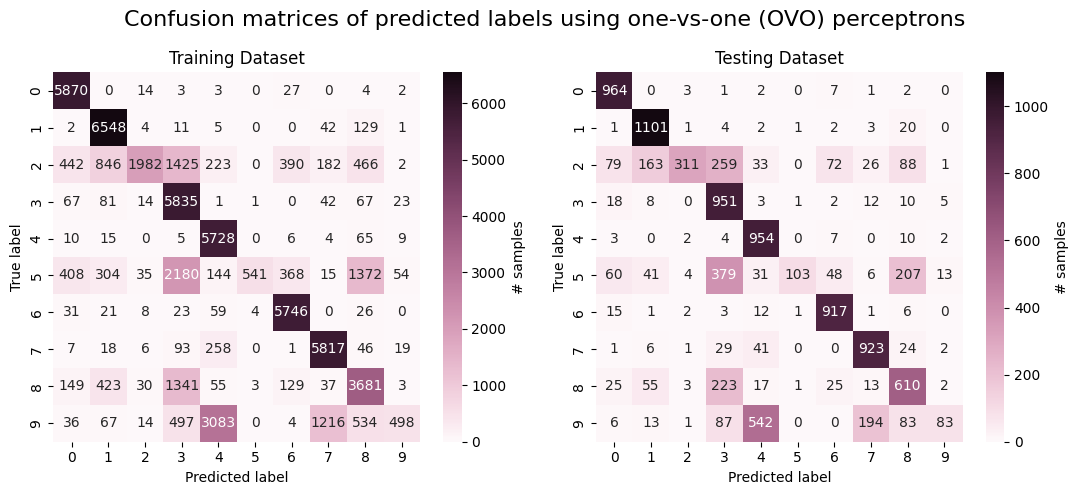

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

confusion_matrix_train = confusion_matrix(y_train, y_train_pred)
confusion_matrix_test = confusion_matrix(y_test, y_test_pred) 

cmap = sns.cubehelix_palette(start=0.5, rot=0.08, dark=0.05, light=0.98, reverse=False, as_cmap=True)

# Plot
fig, axs = plt.subplots(1,2, figsize=(11, 5))

sns.heatmap(confusion_matrix_train,  annot=True, fmt="d", cmap=cmap, ax=axs[0], cbar_kws={"label": "# samples"})
sns.heatmap(confusion_matrix_test, annot = True, fmt = "d", cmap=cmap, ax=axs[1], cbar_kws={"label": "# samples"})

axs[0].set_title("Training Dataset")
axs[0].set_ylabel("True label")
axs[0].set_xlabel("Predicted label")

axs[1].set_title("Testing Dataset")
axs[1].set_ylabel("True label")
axs[1].set_xlabel("Predicted label")

fig.suptitle("Confusion matrices of predicted labels using one-vs-one (OVO) perceptrons", fontsize=16)

plt.tight_layout()
plt.show()



### (ii) Interpret the Results

Analyze the confusion matrices and address the following questions in your report:

**1. Overall Performance**

- **Best performers:** Which digits have the highest diagonal values (most correct predictions)? Is this consistent with Tutorial 4 results for digits 0 and 1?

- **Per-digit accuracy:** How would you compute accuracy for each individual digit from the confusion matrix? Which digits have the lowest accuracy and why might this be? What would you suggest to improve performance on these digits?

- **Generalization:** Compare train vs test confusion matrices. Are the error patterns similar? Does the model generalize well, or do you observe overfitting for certain digits?

**2. Confusion Patterns and Symmetry**

- **Major confusions:** Identify the largest off-diagonal entries (most common mistakes). Speculate on why this confusion occurs based on visual similarity

- **Asymmetric confusions:** Examine whether the confusion matrix is generally not symmetric.  Identify at least two clear asymmetric pairs where confusion[i,j] >> confusion[j,i] and explain why these asymmetries might occur.


<div align="center">

### ✨ End of the Exam ✨

</div>

---

#### Answers

**1. Overall Performance**

The **best performing digits** are 1 and 0 for both training and testing datasets, followed by 3 and 7 (values of correct predictions shown below). The digit 1 performs 55 % above average on train and 59.2 % on test, while zero performs respectively 38.9% and 39.4%. 

The outstanding performance of 0 and 1 digits is coherent with our previous findings. In tutorial 4, we implemented a basic perceptron algorithm to separate the MNIST digits 0 and 1 and obtained small error rates (<0.1%) for both test and train predictions. Furthermore, history tracking allowed us to confirm that the two classes are linearly separable by a hyperplane, as the error reaches approximately 0% after 200-500 iterations. 

The **accuracy of each individual digit** would be the number of correct predictions divided by the total number of predictions.

This low values of accuracy are caused by the weights the vector J obtained by the perceptron algorithm are not being appropriate for separating the between the given digit and another digit. Informally, this means that the digit has least distinctive features that make it easy to tell it apart from the other digits. This can be due to several issues related to the model architecture or to do MNIST dataset itself. The ones related to the model type will be addressed in the section 2. Concerning the MNIST dataset, one first reason is a smaller training dataset: the number 5 is the digit with the least training examples. Another reason is more possibility of inter-handwritting variability between different ways of writting the digits. Finally, a last cause could be the presence of more ambiguous examples. For example, in [this image](https://upload.wikimedia.org/wikipedia/commons/b/b1/MNIST_dataset_example.png ), the eigth digit from left to right of 2 resembles a one, or the 12th digit of 9 resembles a 7 or a 1, and it would be difficult even for a human to tell the difference.

A way to solve this problem while keeping the same model architecture could be to increase the training dataset, perhaps by shuffling the whole dataset into shuffled batches and train the perceptrons of the pairs that have the greatest number of wrong predictions (for example, 2 and 3). 

When we compare test and train confusion matrices, we observe that the model is able to **generalize**: there are no major differences between test and train. We do not observe overfitting for a given digit, that is, a digit for which the test accuracy is much lower than the train. For a more quantitative proof, see below the difference between the row-normalized confusion matrices: the maximum coefficient value is of 0.03; it is practically a null matrix. Despite the magnitudes being different because the train and test dataset are of different sizes, the trends are extremely similar between both datasets. 

**2. Confusion Patterns and Symmetry**

For the results shown in this section, we use mostly the train matrix, but, as we saw above, the tendencies are the same for test.

The **major confusions** given by the largest off-diagonal coefficients are (if true = i and pred = j):

(i=9, j=4) : CM coefficient = 3083

(i=5, j=3) = 2180

(i=2, j=3) = 1425

(i=5, j=8) = 1372

For algorithm to identify them, see in the code below.

We observe that the numbers that are mistaken the one for the other can share some similarities depending on the handwritting. For example, if one writes a more "round" four, it can end up looking very similar to a nine if the upper curvature is more drawn to the inside (again in [this image](https://upload.wikimedia.org/wikipedia/commons/b/b1/MNIST_dataset_example.png ), example of the 8th nine). In the same image, we can understand with the 17th five how it could be mistaken by a three, even by a human. 

I attempted to quantify this similarity by computing the Mean Squared Error (MSE) between two similar digits (4 and 9) versus two dissimilar digits (0 and 1), but the results were not very enlightening. Perhaps, another measure such as [structural similarity index (SSIM)](https://arxiv.org/abs/2006.13846) would be more appropriate.

Some examples of **asymmetric confusions**, *i.e.*, pairs where confusion[i,j]/ confusion[j,i] >> 1  are:

(i=9, j=4) : ratio of confusion[i,j]/ confusion[j,i] = 3038/9 = 342.6

(i=2, j=3) : ratio of 1982/81 = 24.5

(i=9, j=4) : ratio of 1216/19 = 64

(i=9, j=4) : ratio of 2180/1 = 2180

I spent quite some time reflecting on the reason behind asymmetric confusions this and found it difficult to find an answer. It brought me back to the question of how does the perceptron differentiate between two classes (here, it's always two classes because we have one-versus one perceptrons).

We have all these images that are vectors in a 784-dimensional space. The perceptron finds directions that maximally differentiate between these images, and if it is well trained, it can generalize to classes of images. Perhaps, the direction that the one-to-one perceptron found to separate four and nine is not that different (as in orthogonal, in terms of vectors) from the ones that the perceptron found to separate nine and the other numbers. 

For instance, since the perceptron finds these differences by doing a pixel-by-pixel analysis, it could be that the direction it found to differentiate nine and seven is related to the fact that the seven does not have a horizontal line in the middle (while nine has a somehow horizontal-like curvature that closes the round superior part of the number). However, four has this attribute, so maybe the perceptron learned this direction to classify between seven and nine but it works very poorly to classify between nine and four. 

Therefore, perhaps four is better at beign classified by the one-versus-one perceptron because the attributes that differentiate four to each other digit are less superimposable. 

~ for ex, if we think the pixels that form the top part of the number nine, they are often absent (as in, equal to 0) in four, because it has a space on top. ~

This is why perhaps a feature-based model (for instance, features like roundness with eight or zero being very round and one being the least round, number of edges, etc...) could help achieve a better accuracy for numbers like nine. Indeed, nowadays, probably the most common used model to classify the MNIST dataset is a Convolutional Neural Network (CNN), which indirectly performs feature extraction in its convolutional layer and has been linked to the functioning of the visual pathway (cf. Fig. 1 of [Yamis & Dicarlo, 2016](https://www.nature.com/articles/nn.4244)).

In [18]:
cm_train_nodiag = np.abs(confusion_matrix_train - np.diag(confusion_matrix_train))
# get index of maximum off-diagonal element
max_idx = np.unravel_index(np.argmax(cm_train_nodiag, axis=None), cm_train_nodiag.shape)
digit_a, digit_b = max_idx
num_misclassified = cm_train_nodiag[max_idx]
print(f"Most confused digits in training set: {digit_a} and {digit_b} with {num_misclassified} misclassifications.")

Most confused digits in training set: 0 and 1 with 6548 misclassifications.


In [19]:
# 1. Overall performance
# Which digits have performance above the mean ?
diagonal_CM_train = np.diag(confusion_matrix_train)
mean_diag_train = np.mean(diagonal_CM_train)
biggest_idx_train = np.where( diagonal_CM_train > mean_diag_train)
biggest_vals_train = diagonal_CM_train[biggest_idx_train]

diagonal_CM_test = np.diag(confusion_matrix_test)
mean_diag_test = np.mean(diagonal_CM_test)
biggest_idx_test = np.where( diagonal_CM_test > mean_diag_test)
biggest_vals_test = diagonal_CM_test[biggest_idx_test]

print("The digits having best performance are:")
print("On training dataset:")
for i in range(len(biggest_vals_train)):
    print(f"Digit {biggest_idx_train[0][i]} with {biggest_vals_train[i]} correct predictions, {(biggest_vals_train[i] - mean_diag_train)*100/mean_diag_train :.1f} % above average.")
print("On testing dataset:")
for i in range(len(biggest_vals_train)):
    print(f"Digit {biggest_idx_train[0][i]} with {biggest_vals_test[i]} correct predictions, {(biggest_vals_test[i] - mean_diag_test)*100/mean_diag_test :.1f} % above average.")

The digits having best performance are:
On training dataset:
Digit 0 with 5870 correct predictions, 38.9 % above average.
Digit 1 with 6548 correct predictions, 55.0 % above average.
Digit 3 with 5835 correct predictions, 38.1 % above average.
Digit 4 with 5728 correct predictions, 35.6 % above average.
Digit 6 with 5746 correct predictions, 36.0 % above average.
Digit 7 with 5817 correct predictions, 37.7 % above average.
On testing dataset:
Digit 0 with 964 correct predictions, 39.4 % above average.
Digit 1 with 1101 correct predictions, 59.2 % above average.
Digit 3 with 951 correct predictions, 37.5 % above average.
Digit 4 with 954 correct predictions, 37.9 % above average.
Digit 6 with 917 correct predictions, 32.6 % above average.
Digit 7 with 923 correct predictions, 33.4 % above average.


In [20]:
# Accuracy of each digit
accuracy_per_digit_train = diagonal_CM_train / np.sum(confusion_matrix_train, axis=1)
accuracy_per_digit_test = diagonal_CM_test / np.sum(confusion_matrix_test, axis=1)

print("\nAccuracy per digit on training dataset:")
for i in range(len(accuracy_per_digit_train)):
    print(f"Digit {i} : {accuracy_per_digit_train[i]*100 :.2f} %")  
print("\nAccuracy per digit on testing dataset:")
for i in range(len(accuracy_per_digit_test)):
    print(f"Digit {i} : {accuracy_per_digit_test[i]*100 :.2f} %")   


Accuracy per digit on training dataset:
Digit 0 : 99.11 %
Digit 1 : 97.12 %
Digit 2 : 33.27 %
Digit 3 : 95.17 %
Digit 4 : 98.05 %
Digit 5 : 9.98 %
Digit 6 : 97.09 %
Digit 7 : 92.85 %
Digit 8 : 62.91 %
Digit 9 : 8.37 %

Accuracy per digit on testing dataset:
Digit 0 : 98.37 %
Digit 1 : 97.00 %
Digit 2 : 30.14 %
Digit 3 : 94.16 %
Digit 4 : 97.15 %
Digit 5 : 11.55 %
Digit 6 : 95.72 %
Digit 7 : 89.87 %
Digit 8 : 62.63 %
Digit 9 : 8.23 %


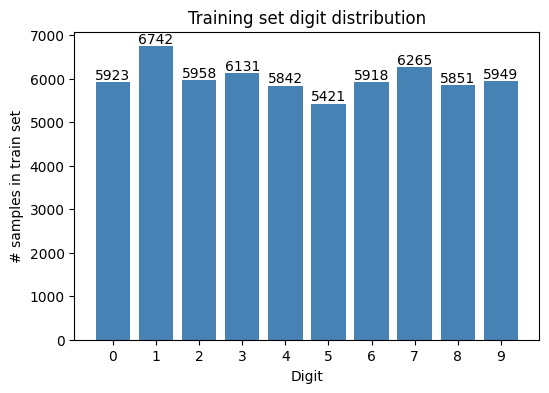

In [21]:
import numpy as np
import matplotlib.pyplot as plt

digits = np.arange(10)
counts = np.array([(y_train == d).sum() for d in digits])

fig, ax = plt.subplots(figsize=(6,4))
bars = ax.bar(digits, counts, color="steelblue")
ax.set_xlabel("Digit")
ax.set_ylabel("# samples in train set")
ax.set_title("Training set digit distribution")
ax.set_xticks(digits)

# Option 1: simple manual labels
for x, c in zip(digits, counts):
    ax.text(x, c, str(c), ha="center", va="bottom")

plt.show()

findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not

Correlation of off-diagonal error patterns: 0.9973358869425702


findfont: Font family ['DejaVu Sans Display'] not found. Falling back to DejaVu Sans.


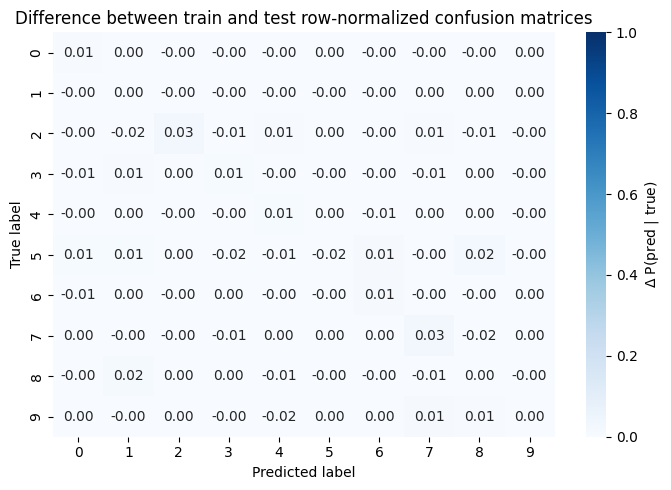

In [22]:
# 2. Confusion patterns and symmetry

import numpy as np
import seaborn as sns

# Suppose you already have:
# y_train, y_train_pred, y_test, y_test_pred

# Convert to float and normalize rows
cm_train = confusion_matrix_train.astype(float)
cm_test  = confusion_matrix_test.astype(float)

row_sums_train = cm_train.sum(axis=1, keepdims=True)
row_sums_test  = cm_test.sum(axis=1, keepdims=True)

cm_train_norm = cm_train / row_sums_train
cm_test_norm  = cm_test  / row_sums_test

# Mask to remove diagonal (correct predictions)
mask_off = ~np.eye(cm_train_norm.shape[0], dtype=bool)

v_train = cm_train_norm[mask_off]
v_test  = cm_test_norm[mask_off]

similarity = np.corrcoef(v_train, v_test)[0, 1]
print("Correlation of off-diagonal error patterns:", similarity)

digits = np.arange(10)  # or whatever labels you have

vmin = 0.0
vmax = 1.0  # since rows are normalized

fig, ax = plt.subplots(figsize=(7, 5))

# Train
sns.heatmap(
    cm_train_norm - cm_test_norm,
    ax=ax,
    vmin=vmin, vmax=vmax,
    cmap="Blues",
    annot=True, fmt=".2f",
    xticklabels=digits, yticklabels=digits,
    cbar_kws={"label": r'$\Delta$ P(pred | true)'}
)
ax.set_title("Difference between train and test row-normalized confusion matrices")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

plt.tight_layout()
plt.show()

In [23]:
import numpy as np

# Off-diagonal elements of cm train
cm_train_nodiag = confusion_matrix_train.copy()
np.fill_diagonal(cm_train_nodiag, 0)

# Flatten, find top‑5, then map back to (i, j)
flat = cm_train_nodiag.flatten()
k = 5 # top 5

idx_flat = np.argpartition(flat, -k)[-k:]              # indices of 5 largest (unordered)
idx_flat = idx_flat[np.argsort(flat[idx_flat])[::-1]]  # sort them descending

i_idx, j_idx = np.unravel_index(idx_flat, cm_train_nodiag.shape)

for i, j in zip(i_idx, j_idx):
    print(i, j, cm_train_nodiag[i, j])

9 4 3083
5 3 2180
2 3 1425
5 8 1372
8 3 1341


In [24]:
def average_image(x, y, digit=0):
    """
    Compute the average image for each digit (0 and 1).

    Parameters
    ----------
    x : array-like, shape (N, 28, 28) 
        Images of digits of size 28 x 28 pixels.
    y : array-like, shape (N,)
        Labels corresponding to the images in x.

    Returns
    -------
    avg_img : ndarray, shape (28, 28)
        Average image.
    """
    x = x.reshape(-1, 28, 28)  # ensure x has shape (N, 28, 28)
    y = np.asarray(y)
    
    # indices of samples labeled as the choisen digit
    digit_idx = np.where(y == digit)[0]

    # get corresponding images 
    digit_x = x[digit_idx, :, :]

    # compute average image
    avg_img = np.mean(digit_x, axis=0)
    return avg_img

# Function for MSE
def mean_squared_error(image1, image2):
    error = np.sum((image1.astype('float') - image2.astype('float'))**2)
    error = error/float(image1.shape[0] * image2.shape[1])
    return error

# compute average images of 4 and 9 (similar-looking numbers) using function
avg_img_4 = average_image(x_train, y_train, digit=4)
avg_img_9 = average_image(x_train, y_train, digit=9)

# compute average images of 5 and 1 (dissimilar-looking numbers) using function
avg_img_5 = average_image(x_train, y_train, digit=5)
avg_img_1 = average_image(x_train, y_train, digit=1)

mean_squared_error_4_9 = mean_squared_error(avg_img_4, avg_img_9)
print(f"Mean Squared Error between average images of digits 4 and 9: {mean_squared_error_4_9:.2f}")

mean_squared_error_5_1 = mean_squared_error(avg_img_5, avg_img_1)
print(f"Mean Squared Error between average images of digits 5 and 1: {mean_squared_error_5_1:.2f}")


Mean Squared Error between average images of digits 4 and 9: 0.01
Mean Squared Error between average images of digits 5 and 1: 0.03


## ➕ Optional (Bonus) Questions

### 🎯 B.5 The Role of the Bias Term

In Tutorial 4, the perceptron learned decision boundaries of the form $J \cdot x = 0$, which must pass through the origin. For many digit pairs, the optimal separating hyperplane needs to be shifted away from the origin. Adding a bias feature $x \rightarrow [x; 1]$ allows the perceptron to learn boundaries of the form $J \cdot x + b = 0$, where the weight corresponding to the bias feature acts as $b$. See the discussion in [1]. Sec. 7.1.1, p. 138.

**Task:**  Implement a function `add_bias_feature(x)` that appends a constant feature (value = 1) to each sample. The function should take an array of shape `(N, features)` and return an array of shape `(N, features+1)` where the last column is all ones.

Add the bonus bias to the MNIST data before splitting into train/test sets. Then, retrain the OVO perceptron system and evaluate performance again. What changes do you observe in accuracy and confusion matrices compared to the no-bias case? Are the (mis-)classification patterns similar or different?

### 🎯 B.6 The Role of Training Budget

Investigate how increasing the `max_updates` parameter during training affects the OVO perceptron performance. Retrain the OVO system with a higher `max_updates=20000` and evaluate accuracy and confusion matrices again. Does training longer lead to significant improvements? Are certain digits more affected by the increased training budget than others? Warining: This may take **10-20** minutes to run!

---


In [ ]:
# B5
# Did not have time to run
def add_bias_feature(X: NDArray[np.float64]) -> NDArray[np.float64]:
    """
    Add a bias feature (X -> [X;1]) to the input data X.

    Parameters
    ----------
    X : ndarray, shape (n_samples, n_features)
        Input data.

    Returns
    -------
    X_bias : ndarray, shape (n_samples, n_features + 1)
        Input data with an added bias feature.
    """
    n_samples = X.shape[0]
    bias_column = np.ones((n_samples, 1))
    X_bias = np.hstack((X, bias_column))
    return X_bias

# Load MNIST data using helper functions
x, y = load_mnist_data("mnist_data", verbose=True)
print("\n")
# Flatten training images x 
x = flatten_images(x, verbose=True)

# Add bias feature to flattened images
x_bias = add_bias_feature(x)

# Splitting the data into train and test sets 
x_train_bias, x_test_bias, y_train, y_test = train_test_split(x = x_bias, y = y, verbose=True)
# Train OVO perceptron system with bias feature
trained_classifiers_bias = train_ovo_perceptron(x_train_bias, y_train, max_updates=20000)
# Run predict_ovo on training and test sets
y_train_pred_bias = predict_ovo(x_train_bias, trained_classifiers_bias)
y_test_pred_bias = predict_ovo(x_test_bias, trained_classifiers_bias)

# Compute training and test errors
print("Training set performance")
print("-"*12)
error_rate_train = compute_error_rate(y_train_pred_bias, y_train_pred_bias, verbose=True)
print(f"Accuracy: {100 * (1 - error_rate_train):.2f}%")
print("\nTest set performance")
print("-"*12)
error_rate_test = compute_error_rate(y_test_pred_bias, y_test_pred_bias, verbose=True)
print(f"Accuracy: {100 * (1 - error_rate_test):.2f}%")

# Confusion Matrices
confusion_matrix_train = confusion_matrix(y_train, y_train_pred_bias)
confusion_matrix_test = confusion_matrix(y_test, y_test_pred_bias) 

cmap = sns.cubehelix_palette(start=0.5, rot=0.08, dark=0.05, light=0.98, reverse=False, as_cmap=True)

# Plot
fig, axs = plt.subplots(1,2, figsize=(11, 5))

sns.heatmap(confusion_matrix_train,  annot=True, fmt="d", cmap=cmap, ax=axs[0], cbar_kws={"label": "# samples"})
sns.heatmap(confusion_matrix_test, annot = True, fmt = "d", cmap=cmap, ax=axs[1], cbar_kws={"label": "# samples"})

axs[0].set_title("Training Dataset")
axs[0].set_ylabel("True label")
axs[0].set_xlabel("Predicted label")

axs[1].set_title("Testing Dataset")
axs[1].set_ylabel("True label")
axs[1].set_xlabel("Predicted label")

fig.suptitle("Confusion matrices of predicted labels using one-vs-one (OVO) perceptrons with 20k updates", fontsize=16)

plt.tight_layout()
plt.show()


In [ ]:
# Did not have time to run 
# B6
from sklearn.metrics import confusion_matrix
import seaborn as sns

trained_classifiers_20k = train_ovo_perceptron(x_train, y_train, max_updates=20000)
# Run predict_ovo on training and test sets
y_train_pred_20k = predict_ovo(x_train, trained_classifiers_20k)
y_test_pred_20k = predict_ovo(x_test, trained_classifiers_20k)

# Compute training and test errors
print("Training set performance")
print("-"*12)
error_rate_train = compute_error_rate(y_train_pred_20k, y_train_pred_20k, verbose=True)
print(f"Accuracy: {100 * (1 - error_rate_train):.2f}%")
print("\nTest set performance")
print("-"*12)
error_rate_test = compute_error_rate(y_test_pred_20k, y_test_pred_20k, verbose=True)
print(f"Accuracy: {100 * (1 - error_rate_test):.2f}%")

# Confusion Matrices
confusion_matrix_train = confusion_matrix(y_train, y_train_pred_20k)
confusion_matrix_test = confusion_matrix(y_test, y_test_pred_20k) 

cmap = sns.cubehelix_palette(start=0.5, rot=0.08, dark=0.05, light=0.98, reverse=False, as_cmap=True)

# Plot
fig, axs = plt.subplots(1,2, figsize=(11, 5))

sns.heatmap(confusion_matrix_train,  annot=True, fmt="d", cmap=cmap, ax=axs[0], cbar_kws={"label": "# samples"})
sns.heatmap(confusion_matrix_test, annot = True, fmt = "d", cmap=cmap, ax=axs[1], cbar_kws={"label": "# samples"})

axs[0].set_title("Training Dataset")
axs[0].set_ylabel("True label")
axs[0].set_xlabel("Predicted label")

axs[1].set_title("Testing Dataset")
axs[1].set_ylabel("True label")
axs[1].set_xlabel("Predicted label")

fig.suptitle("Confusion matrices of predicted labels using one-vs-one (OVO) perceptrons with 20k updates", fontsize=16)

plt.tight_layout()
plt.show()

## 📋 Practical Advice for the Exam

**Work on one part at a time**
- Parts A and B are largely independent - you can complete them in any order
- Recommended order: Part A → Part B (builds conceptual understanding first)

**Start small, then scale up**
- Test your implementations on small datasets/parameters first
- Debug thoroughly before running full experiments
- Save your work frequently!

**Computational tips:**

**If training takes too long:**
Reduce MNIST to digits 0-5 only (15 classifiers instead of 45). Use:
  
```python
def subset_mnist_digits(x, y, digits):
    """
    Subset MNIST data to include only specified digits.
    
    Parameters
    ----------
    x : ndarray, shape (N, 28, 28) or (N, 784)
        MNIST images (either raw or flattened)
    y : ndarray, shape (N,)
        MNIST labels (0-9)
    digits : list, tuple, or array-like
        Which digits to keep (e.g., [0, 1, 2, 3, 4, 5] for digits 0-5)
    
    Returns
    -------
    x_subset : ndarray
        Images for specified digits only
    y_subset : ndarray
        Labels for specified digits only
    
    Examples
    --------
    # Keep only digits 0-5
    x_small, y_small = subset_mnist_digits(x, y, digits=range(6))
    
    # Keep only specific digits
    x_small, y_small = subset_mnist_digits(x, y, digits=[3, 8])
    """
    # Create boolean mask for requested digits
    mask = np.isin(y, digits)
    
    # Apply mask
    x_subset = x[mask]
    y_subset = y[mask]
    
    print(f"Original dataset: {len(y)} samples, {len(np.unique(y))} digits")
    print(f"Subset dataset: {len(y_subset)} samples, {len(np.unique(y_subset))} digits")
    print(f"Digits included: {sorted(np.unique(y_subset))}")
    
    return x_subset, y_subset

# Example: Work with just the first five digits
x, y = load_mnist_data(data_path)
x_subset, y_subset = subset_mnist_digits(x, y, digits=[0, 1, 2, 3, 4, 5])
```

### Debugging Tips

**Verification checklist:**
- Functions return expected shapes
- Reproducibility: same seed → same results
- Small test cases work before scaling up
- Training/test errors are reasonable (not 50% or 100%)

### Getting Unstuck

**Remember:** Partial credit is awarded! 
- Working code with incomplete analysis > Perfect analysis with no code
- Document your attempts and reasoning even if code doesn't fully work
- Focus on demonstrating understanding of concepts

### Final Checks Before Submission

- All code cells run without errors
- Plots are clearly labeled with titles, axes, legends
- Analysis addresses all required questions
- Code is commented and readable
- File is saved as `exam_lastname_firstname.ipynb`

**Good luck! 🍀**